In [1]:
# import statements & checking for cuda
import torch
torch.set_float32_matmul_precision('high')
from ddpm.trainer import LitDDPM
from ddpm.unet import Unet
from helpers import first_radio_galaxy_transform_val, proj_hermitian
from torch.utils.data import DataLoader
from dataset.radio_galaxy_dataset.firstgalaxydata import FIRSTGalaxyData

import numpy as np
from ddrm.svd_replacement import Fourier2D_mask, Fourier2D_weight
from pathlib import Path
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
from matplotlib.colors import LogNorm

device = torch.device('cuda')

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    idx = torch.cuda.current_device()
    print("Current device:", idx)
    print("Name:", torch.cuda.get_device_name(idx))
    x = torch.randn(1, device=f"cuda:{idx}")
    print("Tensor device:", x.device)

import os

/user-environment/env/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
Current device: 0
Name: NVIDIA GH200 120GB
Tensor device: cuda:0


In [2]:
# defining the model

# the image size we use will be 150x150, as set by the pre-trained DDPM
image_size = 150

# define and load the pre-trained DDPM
net = Unet(1, 32, 4, 2, 256).to('cuda')
model = LitDDPM.load_from_checkpoint('/capstor/store/cscs/ska/sk031/last-v5.ckpt', unet=net)

Channel per encoder Depth
[32, 64, 128, 256, 512]


In [22]:
# define the sampling operator used by DDRM

# sampling operator H
mask = torch.from_numpy(np.load('uv_coverages/VLA_mask_150_100steps_uniform.npy'))
weights = torch.from_numpy(np.load('uv_coverages/VLA_mask_150_100steps_natural.npy'))
#print(torch.min(weights[weights>0]))
weights = weights/torch.sum(weights)*torch.sum(mask)
h1 = Fourier2D_mask(channels=1, img_dim=image_size, S=mask, device=device)
h2 = Fourier2D_weight(channels=1, img_dim=image_size, S=weights, device=device)

# number of DDRM sampling steps
# increase this number to improve the image reconstruction
num_steps = 1000

# for a single input image, we will denoise batch_size times
# increase this number to get more samples
batch_size = 1

# sigma is the amount of noise added to visibility space
sigmas = [0.0,0.1,0.2,0.5,1.0]
sigmas = [0.0,0.01,0.02,0.05,0.1]


# the eta hyperparamt 
eta_A, eta_B, eta_C = 0.85, 1.0, 0.85

In [19]:
# for our test data we choose an out-of-domain image
# however, we need to trim/resize this down to our 150x150 input image size
# from PIL import Image
# test_image_file = "letter_E.png"
# im_frame = Image.open(test_image_file)
# true_image = np.array(im_frame.get_flattened_data())
# true_image = np.mean(true_image,axis=-1).reshape(150,150)
# print(true_image.shape)

# #rescale the input image to go from 0 to 1
# shift = np.min(true_image)
# scale = np.max(true_image)
# true_image = 1-(true_image-shift)/(scale-shift)

true_image = np.zeros((150,150))
xs = np.random.random_integers(10,140,10)
ys = np.random.random_integers(10,140,10)
for x in xs:
    for y in ys:
        true_image[x,y] = 1

/tmp/ipykernel_149718/635805046.py:16: DeprecationWarning: This function is deprecated. Please call randint(10, 140 + 1) instead
  xs = np.random.random_integers(10,140,10)
/tmp/ipykernel_149718/635805046.py:17: DeprecationWarning: This function is deprecated. Please call randint(10, 140 + 1) instead
  ys = np.random.random_integers(10,140,10)


In [23]:
# format the true image x_0
x = torch.from_numpy(true_image).reshape(1,image_size, image_size)
x_gpu = x.to(device)
x_0 = x_gpu.unsqueeze(0).repeat(batch_size, 1, 1, 1)
results = []
for sigma_0 in sigmas:
    print("sigma_y = ",sigma_0)
    # define the observation y_0
    y1_0 = h1.H(x_0)
    y1_0 = y1_0 + sigma_0 * proj_hermitian(torch.randn_like(y1_0) * np.sqrt(2))
    
    y2_0 = h2.H(x_0)
    y2_0 = y2_0 + sigma_0 * proj_hermitian(torch.randn_like(y2_0) * np.sqrt(2))
    
    # do the DDRM sampling
    with model.ema.average_parameters():
        model.model.eval()
        x1_hat, _ = model.model.sample_ddrm_y0(
            image_size, num_steps, y1_0, x_0.shape[0], h1, sigma_0, eta_A, eta_B, eta_C
        )
        x2_hat, _ = model.model.sample_ddrm_y0(
            image_size, num_steps, y2_0, x_0.shape[0], h2, sigma_0, eta_A, eta_B, eta_C
        )
    
    # rescale the image estimate x_hat
    x1_hat = ((x1_hat[-1] + 1) / 2).clamp(0, 1)      
    x2_hat = ((x2_hat[-1] + 1) / 2).clamp(0, 1)  
    results.append((y1_0,y2_0,x1_hat,x2_hat))

sigma_y =  0.0
sigma_y =  0.01
sigma_y =  0.02
sigma_y =  0.05
sigma_y =  0.1


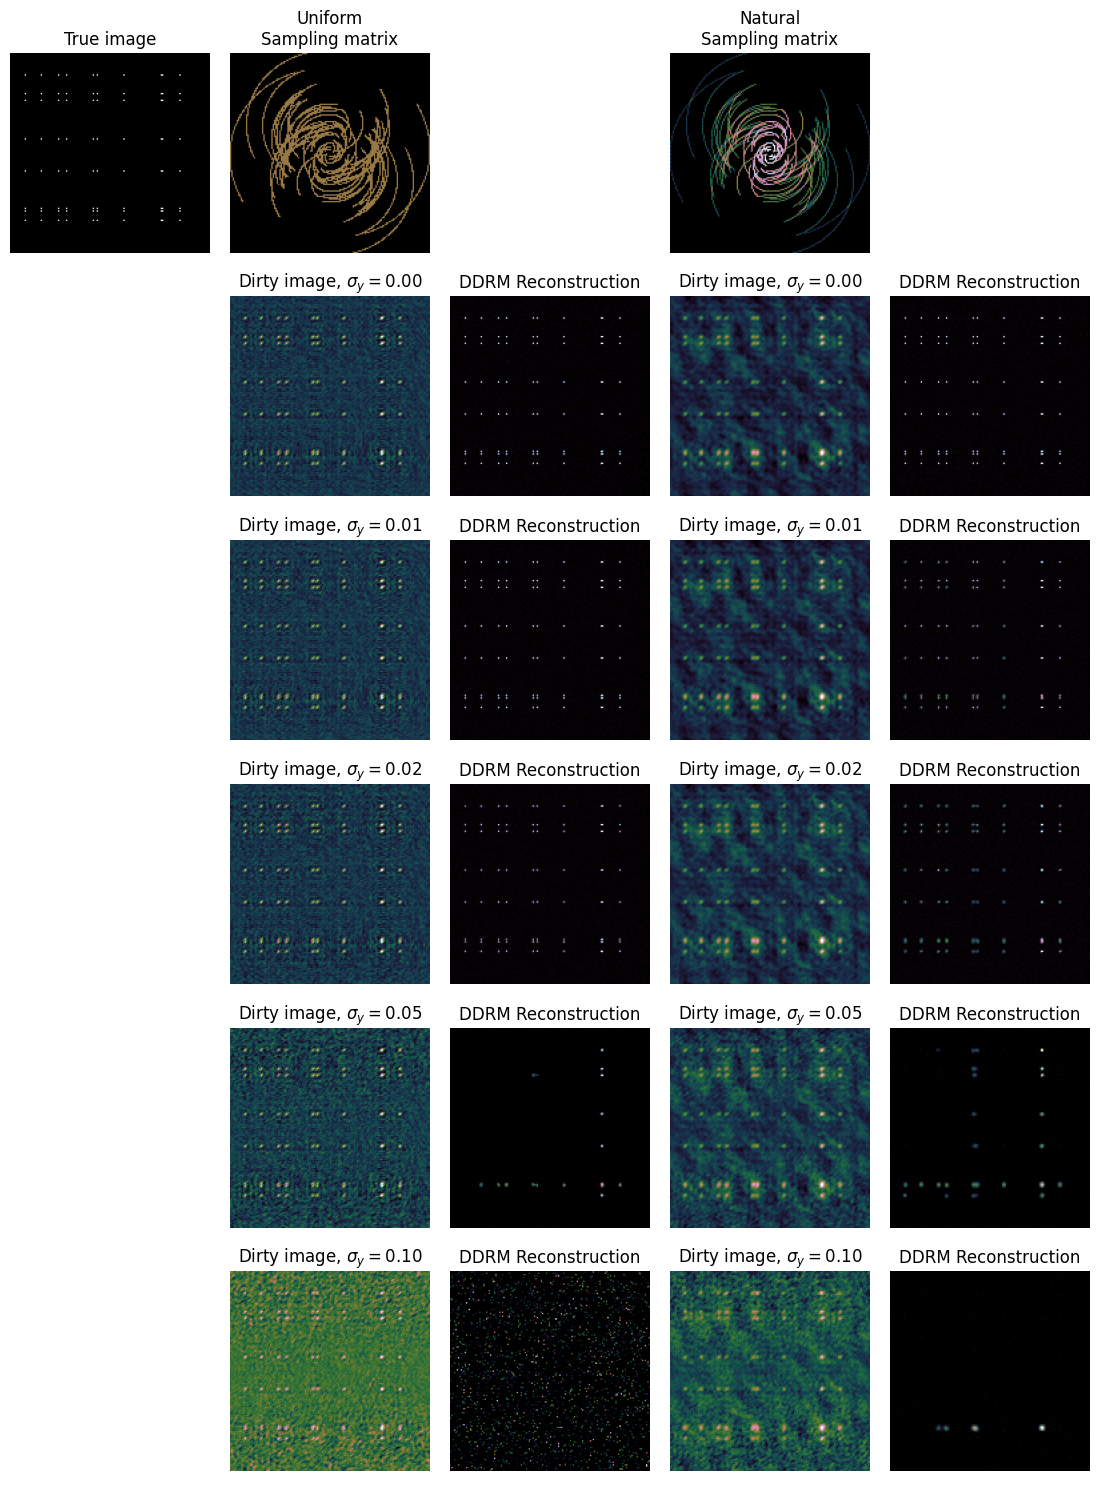

In [24]:
#make plots
fig, ax = plt.subplots(1+len(sigmas),5, figsize=(12, 16))
for a in ax.flatten(): a.set_axis_off()
plt.tight_layout()


colors_negative = plt.cm.CMRmap_r(np.linspace(0.5, 1, 256))
colors_positive = plt.cm.cubehelix(np.linspace(0, 1, 256))
all_colors = np.vstack((colors_negative, colors_positive))
c_map = colors.LinearSegmentedColormap.from_list(
    'c_map', all_colors)

cnorm = colors.SymLogNorm(linthresh=0.01,vmin=0,vmax=.1)
dnorm = colors.SymLogNorm(linthresh=0.1,vmin=-1,vmax=1)
wnorm = colors.SymLogNorm(linthresh=1,vmin=0,vmax=torch.max(weights))
plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.1, hspace = 0.1)
x0 = x.reshape(image_size,image_size)
ax[0][0].imshow(x0,cmap = "cubehelix")
ax[0][0].set_title("True image")

ax[0][1].imshow(mask*1.0,norm=wnorm,cmap = "cubehelix")
ax[0][3].imshow(weights,cmap = "cubehelix",norm=wnorm)
ax[0][1].set_title("Uniform\nSampling matrix")
ax[0][3].set_title("Natural\nSampling matrix")

for i, sigma_0 in enumerate(sigmas):
    y1_0,y2_0,x1_hat,x2_hat = results[i]

    x1_dirty = h1.H_pinv_nosing(y1_0).reshape(batch_size,image_size,image_size).cpu()
    x2_dirty = h2.H_pinv_nosing(y2_0).reshape(batch_size,image_size,image_size).cpu()
    
    ax[i+1][1].imshow(x1_dirty[0,...],cmap ="cubehelix")
    ax[i+1][3].imshow(x2_dirty[0,...],cmap = "cubehelix")
    ax[i+1][1].set_title(r'Dirty image, $\sigma_y=${0:.2f}'.format(sigma_0))
    ax[i+1][3].set_title(r'Dirty image, $\sigma_y=${0:.2f}'.format(sigma_0))
    
    ax[i+1][2].imshow(x1_hat[0,...].reshape(image_size,image_size),cmap = "cubehelix")
    ax[i+1][4].imshow(x2_hat[0,...].reshape(image_size,image_size),cmap = "cubehelix")
    ax[i+1][2].set_title("DDRM Reconstruction")
    ax[i+1][4].set_title("DDRM Reconstruction")

# fig.colorbar(c1,  ax=[ax[0][0],ax[1][0]], shrink=0.75, pad = 0.01,orientation="horizontal")
# fig.colorbar(c2,  ax=[ax[0][1],ax[1][1]], shrink=0.75, pad = 0.01,orientation="horizontal")
# fig.colorbar(c3,  ax=[ax[0][2],ax[1][2]], shrink=0.75, pad = 0.01,orientation="horizontal")
# fig.colorbar(c4,  ax=[ax[0][3],ax[1][3]], shrink=0.75, pad = 0.01,orientation="horizontal")
plt.savefig("fig_dots_s05.pdf")
plt.show()